## OPT-1.3B LoRA Evaluation

In [1]:
import json
import random
import torch
import evaluate
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

## Load Data & Model

In [2]:
DATA_DIR = Path("../data")

def load_clean(file_path):
    data = []
    with open(file_path, "r") as f:
        for line in f:
            data.append(json.loads(line))
    return data

test_raw = load_clean(DATA_DIR / "clean_dolly_test.json")
print(f"Test examples: {len(test_raw)}")

Test examples: 3003


In [3]:
model_id = "facebook/opt-1.3b"
tokenizer = AutoTokenizer.from_pretrained(model_id)

base_model = AutoModelForCausalLM.from_pretrained(
    model_id, device_map="cpu", dtype=torch.float16
)
model = PeftModel.from_pretrained(base_model, "../model/opt_model")
model.eval()
print("model loaded")

config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

d:\miniconda3\envs\ai\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\YASER\.cache\huggingface\hub\models--facebook--opt-1.3b. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

model loaded


In [5]:
def generate_answer(prompt, max_new_tokens=150):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )

    output = tokenizer.decode(out[0], skip_special_tokens=True)
    return output[len(prompt):].strip()

## Balanced Sampling & Inference
Stratified sampling equal examples per category for fair evaluation.

In [6]:
random.seed(42)

by_category = defaultdict(list)
for i, ex in enumerate(test_raw):
    by_category[ex["category"]].append(i)

k_per_cat = min(len(v) for v in by_category.values())
k_per_cat = min(k_per_cat, 5)

print(f"Sampling {k_per_cat} per category ({len(by_category)} categories)")

sample_indices = []
for cat in sorted(by_category):
    sample_indices.extend(random.sample(by_category[cat], k_per_cat))

print(f"Total balanced sample: {len(sample_indices)}")

preds = []
refs = []
categories = []

for idx in sample_indices:
    ex = test_raw[idx]
    prompt = f"Instruction: {ex['instruction']}\n"
    if ex.get("context"):
        prompt += f"Context: {ex['context']}\n"
    prompt += "Answer:"

    out = generate_answer(prompt)
    preds.append(out)
    refs.append(ex["response"])
    categories.append(ex["category"])
    
print("Done")

Sampling 5 per category (8 categories)
Total balanced sample: 40
Done


## Evaluation: BLEU, ROUGE, BERTScore

In [7]:
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

b = bleu.compute(predictions=preds, references=[[r] for r in refs])
r = rouge.compute(predictions=preds, references=refs)
bs = bertscore.compute(predictions=preds, references=refs, lang="en")
avg_bert = sum(bs["f1"]) / len(bs["f1"])

print("=== Overall ===")
print(f"BLEU: {b['bleu']:.4f}")
print(f"ROUGE-1: {r['rouge1']:.4f}  ROUGE-2: {r['rouge2']:.4f}  ROUGE-L: {r['rougeL']:.4f}")
print(f"BERTScore F1: {avg_bert:.4f}")

print("\n=== Per-Category ===")
rows = []
for cat in sorted(set(categories)):
    idxs = [i for i, c in enumerate(categories) if c == cat]
    cat_preds = [preds[i] for i in idxs]
    cat_refs = [refs[i] for i in idxs]
    if len(cat_preds) < 2:
        continue
    cb = bleu.compute(predictions=cat_preds, references=[[r] for r in cat_refs])
    cr = rouge.compute(predictions=cat_preds, references=cat_refs)
    cbs = bertscore.compute(predictions=cat_preds, references=cat_refs, lang="en")
    rows.append({
        "Category": cat,
        "Count": len(idxs),
        "BLEU": round(cb["bleu"], 4),
        "ROUGE-L": round(cr["rougeL"], 4),
        "BERTScore": round(sum(cbs["f1"])/len(cbs["f1"]), 4)
    })

print(pd.DataFrame(rows).to_string(index=False))

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== Overall ===
BLEU: 0.0762
ROUGE-1: 0.2903  ROUGE-2: 0.1503  ROUGE-L: 0.2377
BERTScore F1: 0.8359

=== Per-Category ===
              Category  Count   BLEU  ROUGE-L  BERTScore
         brainstorming      5 0.0213   0.1627     0.8409
        classification      5 0.0936   0.4831     0.8647
             closed_qa      5 0.1822   0.3053     0.8348
      creative_writing      5 0.0064   0.1323     0.8249
            general_qa      5 0.0239   0.1913     0.8422
information_extraction      5 0.0431   0.2816     0.8224
               open_qa      5 0.0000   0.0788     0.7799
         summarization      5 0.1483   0.2879     0.8771


## Sample Outputs

In [11]:
for i in range(min(5, len(preds))):
    idx = sample_indices[i]
    ex = test_raw[idx]
    print(f"Example {i+1} [{categories[i]}]")
    print("Instruction:", ex["instruction"])
    print("Reference:", ex["response"])
    print("OPT Output:", preds[i])
    print("=" * 80)

Example 1 [brainstorming]
Instruction: Give me a list of the best sad songs to play.
Reference: ‘Nothing Compares 2 U’ by Sinéad O’Connor
‘Hurt’ by Johnny Cash
‘Only Love Can Break Your Heart’ by Neil Young
‘Teardrop’ by Massive Attack
‘I Know It’s Over’ by The Smiths
‘No Distance Left to Run’ by Blur
‘The Boxer’ by Simon & Garfunkel
‘Tom Traubert’s Blues (Four Sheets to the Wind in Copenhagen)’ by Tom Waits
‘Lazarus’ by David Bowie
OPT Output: The best sad songs to play are songs about death, loss and grief.  Here are some of the best songs to play to help you get through the day:
1. "One Last Dance" by The Band Perry
2. "I'll Be There For You" by The Band Perry
3. "Carry On Wayward Son" by The Band Perry
4. "The End" by The Band Perry
5. "I Can't Stand The Rain" by The Band Perry
6. "Walking In The Rain" by The Band Perry
7. "I'll Be There For You" by The Band Perry
8. "I'll Carry You Home" by The Band Perry
9. "You're
Example 2 [brainstorming]
Instruction: What are four creative way

### Cross-Model Analysis

| Model | Type | Parameters |
|-------|------|-----------|
| DeepSeek | API (cloud) | ~67B |
| TinyLlama + LoRA | Local fine-tuned (instruction-tuned base) | 1.1B |
| OPT-1.3B + LoRA | Local fine-tuned (base model) | 1.3B |

Comparing two LoRA-adapted models of similar size but different starting points: TinyLlama is already instruction-tuned while OPT is a base language model. This reveals how much the base model's pretraining matters for instruction-following after fine-tuning.

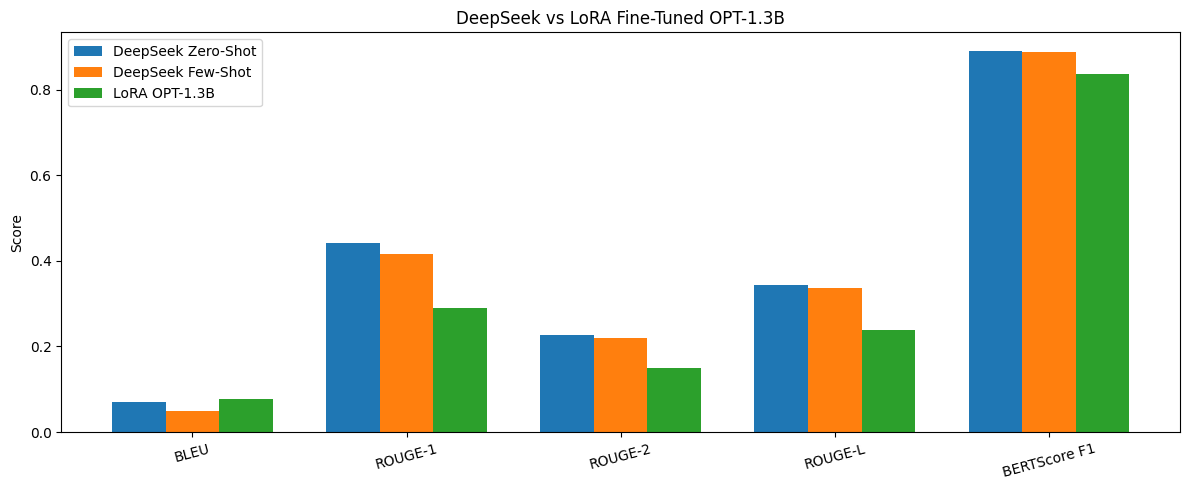

In [12]:
deep_results = pd.read_csv("zero_vs_few_comparison.csv")

# OPT metrics from current eval
opt_metrics = [b['bleu'], r['rouge1'], r['rouge2'], r['rougeL'], avg_bert]

# Build comparison DataFrame
comparison = pd.DataFrame({
    "Metric": deep_results["Metric"],
    "DeepSeek Zero-Shot": deep_results["Zero-Shot"],
    "DeepSeek Few-Shot": deep_results["Few-Shot"],
    "LoRA OPT-1.3B": opt_metrics
})

metrics = comparison["Metric"].tolist()
x = range(len(metrics))
w = 0.25

plt.figure(figsize=(12, 5))
plt.bar([i - w for i in x], comparison["DeepSeek Zero-Shot"], width=w, label="DeepSeek Zero-Shot")
plt.bar(list(x), comparison["DeepSeek Few-Shot"], width=w, label="DeepSeek Few-Shot")
plt.bar([i + w for i in x], comparison["LoRA OPT-1.3B"], width=w, label="LoRA OPT-1.3B")
plt.xticks(x, metrics, rotation=15)
plt.ylabel("Score")
plt.title("DeepSeek vs LoRA Fine-Tuned OPT-1.3B")
plt.legend()
plt.tight_layout()
plt.show()